In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
data = pd.read_csv(r'car data.csv')

In [3]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
data.duplicated().sum()          
data[data['Driven_kms'] > 500000]  
data[data['Selling_Price'] > data['Present_Price']]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner


In [8]:
print(data.duplicated().sum()) 
print(data['Driven_kms'].describe())

2
count       301.000000
mean      36947.205980
std       38886.883882
min         500.000000
25%       15000.000000
50%       32000.000000
75%       48767.000000
max      500000.000000
Name: Driven_kms, dtype: float64


In [9]:
data.drop_duplicates(inplace=True)
print(data.shape)

(299, 9)


In [10]:
data[data['Driven_kms'] == 500000]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0


In [11]:
data.reset_index()

,index,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...,...
294,296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
295,297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
296,298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
297,299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [12]:
data['Year'].unique()

array([2014, 2013, 2017, 2011, 2018, 2015, 2016, 2009, 2010, 2012, 2003,
       2008, 2006, 2005, 2004, 2007])

In [13]:
data['Car_Age'] = 2025 - data['Year'] 

def age_group(age):
    if age < 5:
        return 'New'
    elif age <= 15:
        return 'Mid-Age'
    else:
        return 'Old'

data['Age_Group'] = data['Car_Age'].apply(age_group)
print(data['Age_Group'].value_counts())

Age_Group
Mid-Age    273
Old         26
Name: count, dtype: int64


<Figure size 1200x800 with 0 Axes>

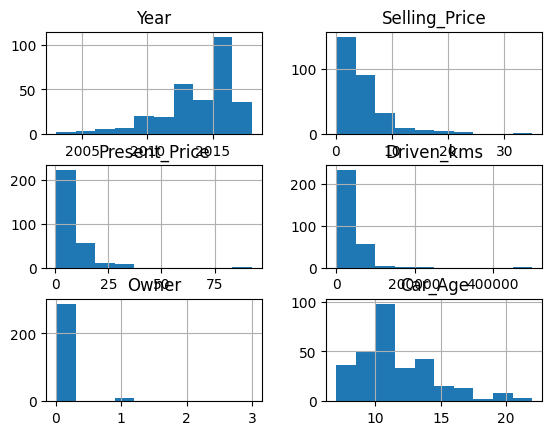

In [14]:
plt.figure(figsize=(12,8))
data.hist()
plt.show()

<Figure size 1200x800 with 0 Axes>

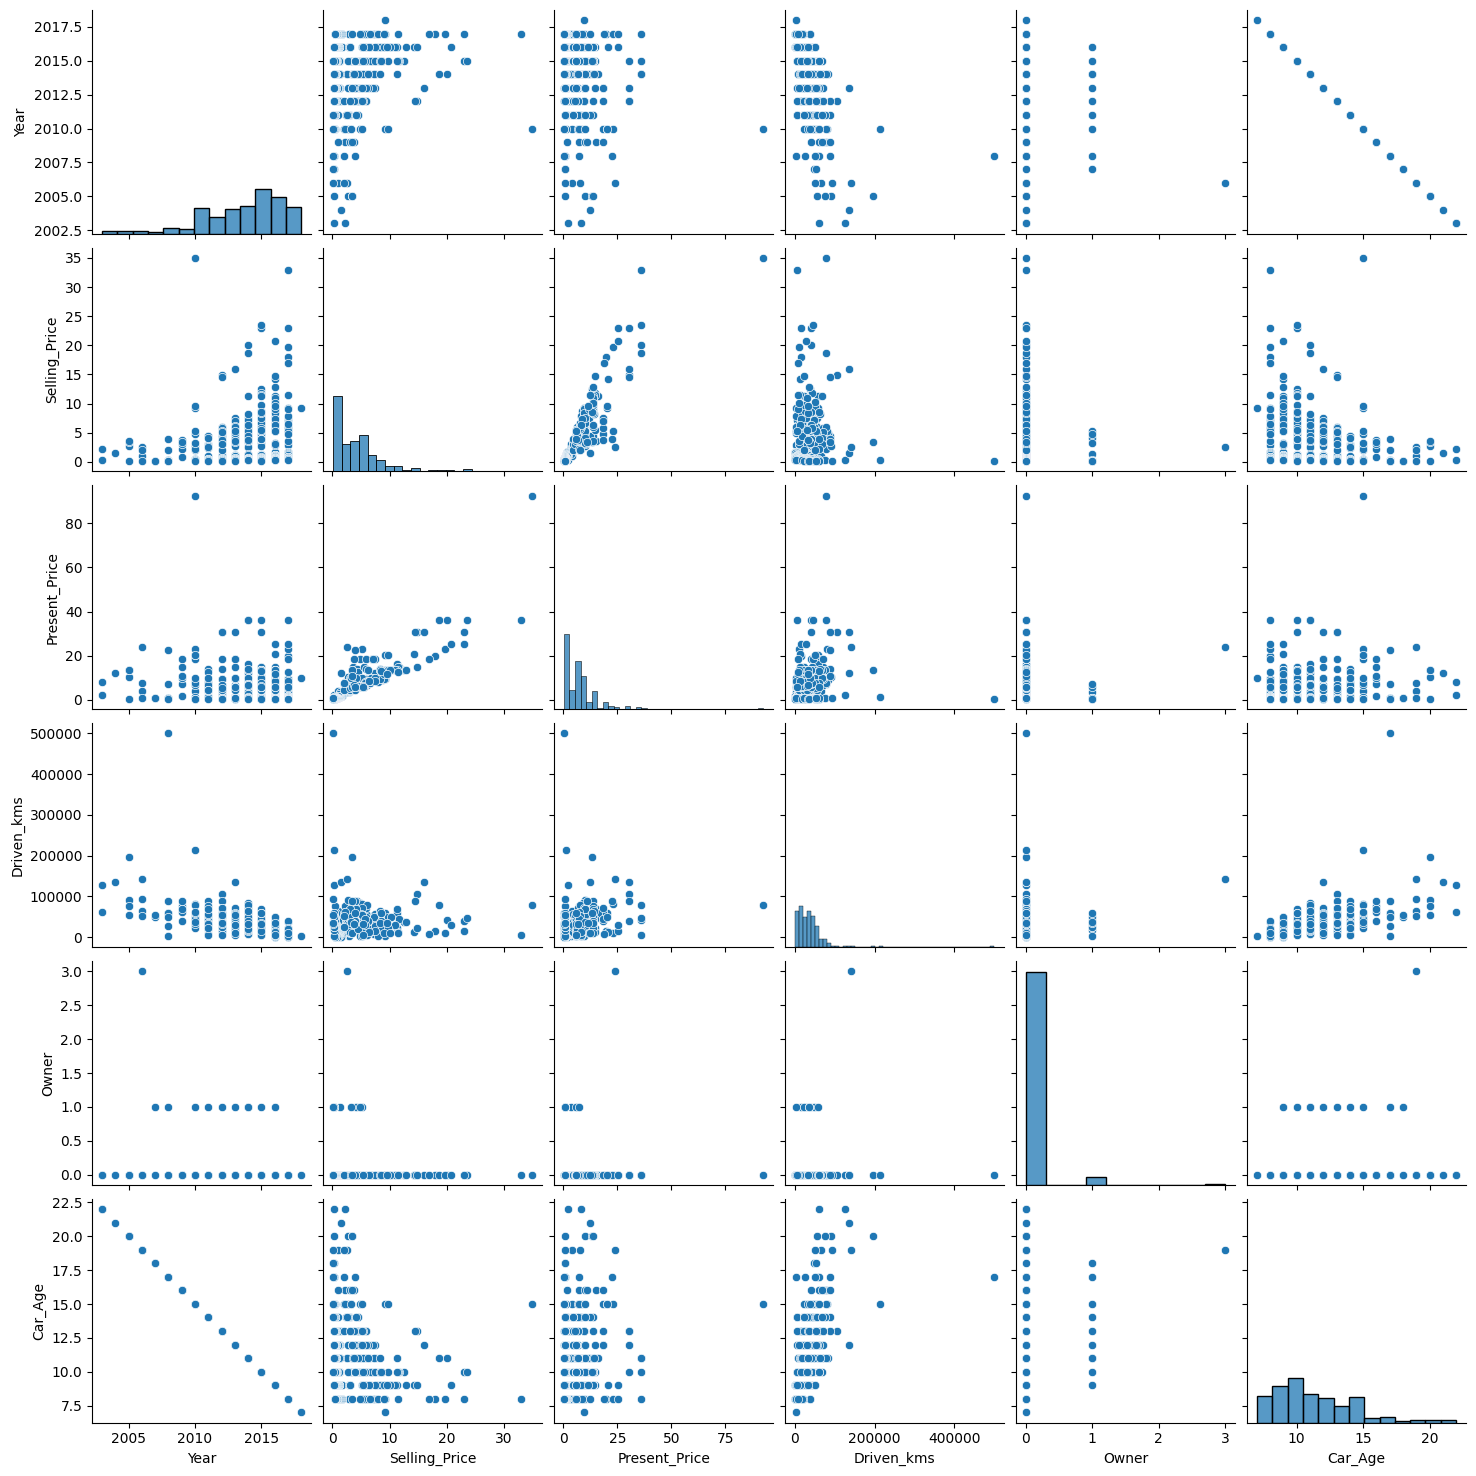

In [15]:
plt.figure(figsize=(12,8))
sns.pairplot(data) 
plt.show()

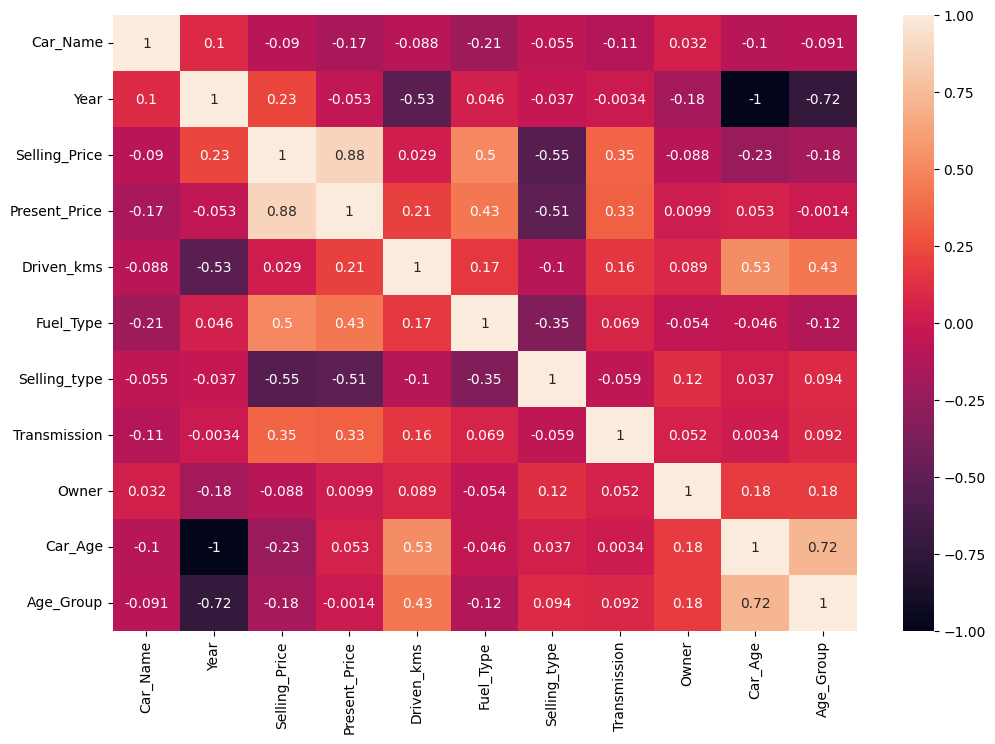

In [16]:
plt.figure(figsize=(12,8))
data_encoded = data.copy()
for col in data_encoded.select_dtypes(include='object').columns:
    data_encoded[col] = pd.factorize(data_encoded[col])[0]
sns.heatmap(data_encoded.corr(), annot=True) 
plt.show()

In [17]:
data['Deprecation'] = data['Present_Price'] - data['Selling_Price'] 
data['Deprecation_Rate'] = (data['Deprecation'] / data['Present_Price']) * 100 

In [18]:
data['km_Per_year'] = data['Driven_kms'] / data['Car_Age'] 

In [19]:
data['Owner'].unique()

array([0, 1, 3])

In [20]:
data['Transmission_Numeric'] = (data['Transmission'] == 'Manual').astype(int)

print(data['Transmission_Numeric'].value_counts())

Transmission_Numeric
1    260
0     39
Name: count, dtype: int64


In [21]:
data['Is_First_Owner'] = (data['Owner'] == 0).astype(int)
data['Is_Diesel']      = (data['Fuel_Type'] == 1).astype(int)  
data['Is_Automatic']   = (data['Transmission'] == 'Automatic').astype(int)
data['Is_Dealer']      = (data['Selling_type'] == 'Dealer').astype(int)

print(data[['Is_First_Owner','Is_Diesel','Is_Automatic','Is_Dealer']].value_counts())

Is_First_Owner  Is_Diesel  Is_Automatic  Is_Dealer
1               0          0             1            161
                                         0             89
                           1             1             28
                                         0             10
0               0          0             0              6
                                         1              4
                           1             0              1
Name: count, dtype: int64


In [22]:
data.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Age_Group,Deprecation,Deprecation_Rate,km_Per_year,Transmission_Numeric,Is_First_Owner,Is_Diesel,Is_Automatic,Is_Dealer
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,Mid-Age,2.24,40.071556,2454.545455,1,1,0,0,1
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,Mid-Age,4.79,50.209644,3583.333333,1,1,0,0,1
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,Mid-Age,2.60,26.395939,862.500000,1,1,0,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,Mid-Age,1.30,31.325301,371.428571,1,1,0,0,1
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,Mid-Age,2.27,33.042213,3859.090909,1,1,0,0,1


In [23]:
pip install plotly 

Note: you may need to restart the kernel to use updated packages.


In [24]:
import plotly.express as px 

age_group_sales = (data.groupby('Age_Group')['Selling_Price']
                .mean()
                .reset_index())
age_group_sales.columns = ['Age_Group', 'Avg_Selling_Price']

fig = px.bar(age_group_sales,
            x='Age_Group',
            y='Avg_Selling_Price',
            title='Avg Selling Price by Age Group',
            color='Avg_Selling_Price',
            color_continuous_scale='Reds',
            text='Avg_Selling_Price',
            template='plotly_dark',
            height=500)

fig.update_traces(textposition='outside', texttemplate='%{y:.2f}L')
fig.update_layout(
xaxis_title='Age Group',
yaxis_title='Avg Selling Price (L)'
)
fig.show() 

age_group_full = data.groupby('Age_Group').agg(
    Avg_Price = ('Selling_Price' , 'mean') , 
    Count = ('Selling_Price' , 'count')
).reset_index() 

print(age_group_full)

  Age_Group  Avg_Price  Count
0   Mid-Age   4.865421    273
1       Old   1.693846     26


In [25]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age',
       'Age_Group', 'Deprecation', 'Deprecation_Rate', 'km_Per_year',
       'Transmission_Numeric', 'Is_First_Owner', 'Is_Diesel', 'Is_Automatic',
       'Is_Dealer'],
      dtype='object')

In [26]:
fig = px.box(data, 
            x='Age_Group', 
            y='Selling_Price',
            color='Age_Group',
            title='Selling Price Distribution — Old vs Mid-Age',
            template='plotly_dark',
            height=500)
fig.show()

fig = px.box(data,
            x='Age_Group',
            y='Deprecation_Rate',
            color='Age_Group',
            title='Deprecation_Rate — Old vs Mid-Age',
            template='plotly_dark',
            height=500)
fig.show()

### Which cars are the most selling ? 

In [27]:
import plotly.express as px

car_counts = data['Car_Name'].value_counts().reset_index()
car_counts.columns = ['Car_Name', 'Count']

fig = px.bar(car_counts.head(10),
            x='Car_Name', 
            y='Count',
            title='Top 10 Cars by Sales',
            color='Count',
            color_continuous_scale='reds',
            text='Count',
            height=600)

fig.update_traces(textposition='outside', texttemplate='%{y:.0f}')
fig.update_xaxes(tickangle=45)
fig.update_layout(
    xaxis_title='Car',
    yaxis_title='Sales'
)
fig.show()

## Cars with low selling 

In [28]:
import plotly.express as px

car_counts = data['Car_Name'].value_counts().reset_index()
car_counts.columns = ['Car_Name', 'Count']

fig = px.bar(car_counts.tail(10),
            x='Car_Name', 
            y='Count',
            title='Top 10 Cars by Sales',
            color='Count',
            color_continuous_scale='reds',
            text='Count' , 
            height = 600 ) 
fig.update_traces(textposition='outside', texttemplate='%{y:.0f}')
fig.update_xaxes(tickangle=45)
fig.update_layout(
    xaxis_title='Car',
    yaxis_title='Sales'
)
fig.show()

## Cars With most Average selling price 

In [29]:
car_avg_price = (data.groupby('Car_Name')['Selling_Price']
                .mean()
                .reset_index()
                .sort_values('Selling_Price', ascending=False)
                .head(10))
car_avg_price.columns = ['Car_Name', 'Avg_Price']

fig = px.bar(car_avg_price,
            x='Car_Name',
            y='Avg_Price',
            title='Top 10 Cars by Average Selling Price',
            color='Avg_Price',
            color_continuous_scale='Reds',
            text='Avg_Price',
            height=600)

fig.update_traces(textposition='outside', texttemplate='%{y:.2f}L')
fig.update_xaxes(tickangle=45)
fig.update_layout(
    xaxis_title='Car',
    yaxis_title='Avg Price (Lakhs)'
)
fig.show()

In [30]:
data.rename(columns={
    'Deprecation': 'Depreciation',
    'Deprecation_Rate': 'Depreciation_Rate'
}, inplace=True)

In [31]:
car_avg_depreciation = (data.groupby('Car_Name')['Depreciation']
                        .mean()
                        .reset_index()
                        .sort_values('Depreciation', ascending=False)
                        .head(10))

fig = px.bar(car_avg_depreciation,
            x='Car_Name',
            y='Depreciation',
            title='Top 10 Cars by Average Depreciation',
            color='Depreciation',
            color_continuous_scale='Reds',
            text='Depreciation',
            height=600)

fig.update_traces(textposition='outside', texttemplate='%{y:.2f}L')
fig.update_xaxes(tickangle=45)
fig.update_layout(
    xaxis_title='Car',
    yaxis_title='Avg Depreciation (Lakhs)'
)
fig.show()

In [32]:
avg_price = (data.groupby('Car_Name')['Selling_Price']
            .mean()
            .reset_index()) 
avg_price.columns = ['Car_Name', 'Avg_Price'] 

sales_count = (data['Car_Name']
            .value_counts()
            .reset_index())
sales_count.columns = ['Car_Name', 'Count'] 
combined = avg_price.merge( 
    sales_count, on='Car_Name', how='inner'
) 

combined = combined.sort_values('Count',ascending = False)
combained = combined.sort_values('Avg_Price' , ascending = False)
print(combined.head(10))

                     Car_Name  Avg_Price  Count
69                       city   7.419231     26
71              corolla altis   7.183125     16
94                      verna   6.107857     14
66                       brio   4.745000     10
81                   fortuner  18.254000     10
86                     innova  12.777778      9
84                        i20   4.766667      9
68                       ciaz   7.472222      9
82                  grand i10   4.943750      8
46  Royal Enfield Classic 350   1.144286      7


In [33]:
fig = px.bar(combined.sort_values('Count', ascending=False).head(10),
            x='Car_Name',
            y='Count',
            title='Top 10 Cars — Sales Count vs Avg Price',
            color='Avg_Price',
            color_continuous_scale='Reds',
            text='Count',
            height=600)

fig.update_traces(textposition='outside', texttemplate='%{y:.0f}')
fig.update_xaxes(tickangle=45)
fig.update_layout(
    xaxis_title='Car',
    yaxis_title='Sales Count',
    coloraxis_colorbar=dict(title='Avg Price (L)')  )
fig.show()

In [34]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age',
       'Age_Group', 'Depreciation', 'Depreciation_Rate', 'km_Per_year',
       'Transmission_Numeric', 'Is_First_Owner', 'Is_Diesel', 'Is_Automatic',
       'Is_Dealer'],
      dtype='object')

In [35]:
avg_price_transmission = (data.groupby('Transmission')['Selling_Price']
                        .mean()
                        .reset_index())
avg_price_transmission.columns = ['Transmission', 'Avg_Price']

fig = px.bar(avg_price_transmission,
            x='Transmission',
            y='Avg_Price',
            title='Automatic vs Manual —  Avg price Selling Transmission',
            color='Transmission',
            color_discrete_map={'Manual': 'steelblue', 'Automatic': 'crimson'},
            text='Avg_Price',
            height=500,
            template='plotly_dark')

fig.update_traces(textposition='outside', texttemplate='%{y:.2f}L')
fig.update_layout(
    xaxis_title='Transmission',
    yaxis_title='Avg Selling Price (L)',
    showlegend=False
)
fig.show() 

avg_depreciation_transmission= (data.groupby('Transmission')['Depreciation_Rate']
                        .mean() 
                        .sort_values(ascending=False)
                        .reset_index() 
)

avg_depreciation_transmission.columns = ['Transmission', 'Avg_Depreciation_Rate']

fig = px.bar(avg_depreciation_transmission,
            x='Transmission',
            y='Avg_Depreciation_Rate',
            title='Automatic vs Manual —  Avg depreciation Rate Transmission',
            color='Transmission',
            color_discrete_map={'Manual': 'steelblue', 'Automatic': 'crimson'},
            text='Avg_Depreciation_Rate',
            height=500,
            template='plotly_dark')

fig.update_traces(textposition='outside', texttemplate='%{y:.2f}%')
fig.update_layout(
    xaxis_title='Transmission',
    yaxis_title='Avg depreciation Rate %',
    showlegend=False
)
fig.show() 

In [36]:
transmission_counts = data['Transmission'].value_counts().reset_index()
fig = px.pie(transmission_counts,
        names='Transmission',
        values='count',
        title='Distrubation of Manual vs Automatic on data',
        template='plotly_dark')
fig.show()

In [37]:
car_name_depreciation = (data.groupby('Car_Name')['Depreciation_Rate']
                        .mean()
                        .reset_index()
                        .sort_values('Depreciation_Rate', ascending=False)
                        .head(10))
car_name_depreciation.columns = ['Car_Name', 'Avg_Depreciation_Rate']

fig = px.bar(car_name_depreciation,
            x='Car_Name',
            y='Avg_Depreciation_Rate',
            title='Top 10 Cars by Avg Depreciation Rate',
            color='Avg_Depreciation_Rate',
            color_continuous_scale='Reds',
            text='Avg_Depreciation_Rate',
            template='plotly_dark',
            height=600)

fig.update_traces(textposition='outside', texttemplate='%{y:.1f}%')
fig.update_xaxes(tickangle=45)
fig.update_layout(
xaxis_title='Car Name',
yaxis_title='Avg Depreciation Rate %'
)
fig.show()

## Fuel Type 

In [38]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fuel_type_sales = data.groupby('Fuel_Type').agg(
    Car_Count=('Car_Name', 'count'),
    Avg_Car_Age=('Car_Age', 'mean'),
    Avg_Selling_Price=('Selling_Price', 'mean'),
    Avg_Depreciation_Rate=('Depreciation_Rate', 'mean')
).reset_index()

print(fuel_type_sales)

colors = ['#e74c3c', '#3498db', '#2ecc71']

fig = make_subplots(rows=2, cols=2,
    subplot_titles=(
        'Fuel Type vs Avg Selling Price',
        'Fuel Type vs Avg Depreciation Rate' , 
        'Fuel Type vs Car Count' , 
        'Fuel Type vs Avg Car Age '
    )
)

fig.add_trace(go.Bar(
    x=fuel_type_sales['Fuel_Type'],
    y=fuel_type_sales['Avg_Selling_Price'].round(2),
    marker_color=colors,
    text=fuel_type_sales['Avg_Selling_Price'].round(2),
    name='Avg Price'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=fuel_type_sales['Fuel_Type'],
    y=fuel_type_sales['Avg_Depreciation_Rate'].round(1),
    marker_color=colors,
    text=fuel_type_sales['Avg_Depreciation_Rate'].round(1),
    name='Depreciation'
), row=1, col=2)

fig.add_trace(go.Bar(
    x = fuel_type_sales['Fuel_Type'] , 
    y = fuel_type_sales['Car_Count'].round(1) , 
    marker_color = colors , 
    text = fuel_type_sales['Car_Count'].round(1) , 
    name = 'Car Count'
), row =2 , col=1)

fig.add_trace(go.Bar(
    x = fuel_type_sales['Fuel_Type'] , 
    y = fuel_type_sales['Avg_Car_Age'].round(1) , 
    marker_color = colors , 
    text = fuel_type_sales['Avg_Car_Age'].round(1) , 
    name = 'Avg Car Age'
), row =2 , col=2)  

fig.update_layout(
    title_text='How Fuel Type Effects on Price & Depreciation',
    template='plotly_dark',
    height=500,
    showlegend=False
)
fig.update_traces(textposition='auto', cliponaxis=False)
fig.show()

  Fuel_Type  Car_Count  Avg_Car_Age  Avg_Selling_Price  Avg_Depreciation_Rate
0       CNG          2    12.000000           3.100000              49.017809
1    Diesel         58    11.051724          10.102759              32.225727
2    Petrol        239    11.460251           3.264184              37.611815


## OWNER

In [39]:
def owner_group(owner): 
    if owner == 0:
        return 'First'
    elif owner == 1:
        return 'Second'
    else:
        return 'Third or More' 

data['Owner_Group'] = data['Owner'].apply(owner_group)
print(data['Owner_Group'].value_counts())

Owner_Group
First            288
Second            10
Third or More      1
Name: count, dtype: int64


In [40]:
owner_analysis = data.groupby('Owner_Group').agg(
    Car_Count=('Car_Name', 'count'),
    Avg_Car_Age=('Car_Age', 'mean'),
    Avg_Selling_Price=('Selling_Price', 'mean'),
    Avg_Depreciation_Rate=('Depreciation_Rate', 'mean')
).reset_index()

order = ['First', 'Second', 'Third or More']
owner_analysis['Owner_Group'] = pd.Categorical(
    owner_analysis['Owner_Group'], 
    categories=order, 
    ordered=True
)
owner_analysis = owner_analysis.sort_values('Owner_Group')

print(owner_analysis)

     Owner_Group  Car_Count  Avg_Car_Age  Avg_Selling_Price  \
0          First        288    11.302083           4.687847   
1         Second         10    13.000000           1.970000   
2  Third or More          1    19.000000           2.500000   

   Avg_Depreciation_Rate  
0              35.850951  
1              54.181302  
2              89.464812  


In [41]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Car Counts for each Owner Type',
        'Car Age Average for each Owner Type',
        'Car Selling Avg for each Owner Type',
        'Car Depreciation Rate Avg for each Owner Type'
    )
)

colors = ['#2ecc71', '#e74c3c', '#9b59b6']

fig.add_trace(go.Bar(
    x=owner_analysis['Owner_Group'],
    y=owner_analysis['Car_Count'],
    marker_color=colors,
    text=owner_analysis['Car_Count'],
    textposition='outside',
    name='Count'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=owner_analysis['Owner_Group'],
    y=owner_analysis['Avg_Car_Age'].round(1),
    marker_color=colors,
    text=owner_analysis['Avg_Car_Age'].round(1),
    textposition='outside',
    name='Car Age'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=owner_analysis['Owner_Group'],
    y=owner_analysis['Avg_Selling_Price'].round(2),
    marker_color=colors,
    text=owner_analysis['Avg_Selling_Price'].round(2),
    textposition='outside',
    name='Avg Car Selling'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=owner_analysis['Owner_Group'],
    y=owner_analysis['Avg_Depreciation_Rate'].round(1),
    marker_color=colors,
    text=owner_analysis['Avg_Depreciation_Rate'].round(1),
    textposition='outside',
    name='Depreciation'
), row=2, col=2)

fig.update_layout(
    title_text='How Type of Owners Can Effect on the Decision of Selling or Buying Car',
    template='plotly_dark',
    height=700,
    showlegend=False
)

fig.update_traces(
    textposition='auto',   
    cliponaxis=False      
)

fig.show()


### Selling Type 

In [42]:
Selling_Type = data.groupby('Selling_type').agg(
    Car_Count=('Car_Name', 'count'),
    Avg_Car_Age=('Car_Age', 'mean'),
    Avg_Selling_Price=('Selling_Price', 'mean'),
    Avg_Depreciation_Rate=('Depreciation_Rate', 'mean')
).reset_index() 

print(Selling_Type)

  Selling_type  Car_Count  Avg_Car_Age  Avg_Selling_Price  \
0       Dealer        193    11.305699           6.632021   
1   Individual        106    11.528302           0.870943   

   Avg_Depreciation_Rate  
0              36.127352  
1              37.582761  


In [43]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Car Counts for each Selling Type',
        'Car Age Average for each Selling Type',
        'Car Selling Avg for each Selling Type',
        'Car Depreciation Rate Avg for each Selling Type'
    )
)

colors = ['#3498db', '#e74c3c']   

fig.add_trace(go.Bar(
    x=Selling_Type['Selling_type'],
    y=Selling_Type['Car_Count'],
    marker_color=colors,
    text=Selling_Type['Car_Count'],
    textposition='outside',
    name='Count'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=Selling_Type['Selling_type'],
    y=Selling_Type['Avg_Car_Age'].round(1),
    marker_color=colors,
    text=Selling_Type['Avg_Car_Age'].round(1),
    textposition='outside',
    name='Car Age'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=Selling_Type['Selling_type'],
    y=Selling_Type['Avg_Selling_Price'].round(2),
    marker_color=colors,
    text=Selling_Type['Avg_Selling_Price'].round(2),
    textposition='outside',
    name='Avg Car Selling'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=Selling_Type['Selling_type'],
    y=Selling_Type['Avg_Depreciation_Rate'].round(1),
    marker_color=colors,
    text=Selling_Type['Avg_Depreciation_Rate'].round(1),
    textposition='outside',
    name='Depreciation'
), row=2, col=2)

fig.update_layout(
    title_text='How Type of Selling Can Effect on the Decision of Selling or Buying Car',
    template='plotly_dark',
    height=700,
    showlegend=False
)

fig.update_traces(
    textposition='auto',   
    cliponaxis=False      
)

fig.show()

In [44]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age',
       'Age_Group', 'Depreciation', 'Depreciation_Rate', 'km_Per_year',
       'Transmission_Numeric', 'Is_First_Owner', 'Is_Diesel', 'Is_Automatic',
       'Is_Dealer', 'Owner_Group'],
      dtype='object')

## KM

In [45]:
data['Driven_kms'].unique()

array([ 27000,  43000,   6900,   5200,  42450,   2071,  18796,  33429,
        20273,  42367,   2135,  51000,  15000,  26000,  77427,  41678,
        35500,  41442,  25000,   2400,  50000,  45280,  56879,  20000,
        55138,  16200,  44542,  45000,  51439,  54200,  39000,  49998,
        48767, 127000,  10079,  62000,  24524,  46706,  58000,  45780,
        64532,  65000,  25870,  37000, 104707,  40000, 135000,  90000,
        70000,  40534,  39485,  41000,  40001,  40588,  78000,  47000,
         6000,  11000,  59000,  88000,  12000,  71000,  56001,  83000,
        36000,  72000, 135154,  80000,  89000,  23000,  38000, 197176,
       142000,  56000,  58242,  75000,  29000,   8700,  50024,   3000,
         1400,   4000,   1200,   4100,  21700,  16500,  18000,   7000,
        35000,  17000,  17500,  33000,  14000,   5400,   5700,  46500,
        11500,   1300,   5000,   3500,    500,  11800,  23500,  16000,
        16600,  32000,  19000,  24000,  31000,  13000,   8000,   4300,
      

In [46]:
def km_category(km):
    if km < 50000:
        return 'Low'
    elif km <= 100000:
        return 'Medium'
    else:
        return 'High'

data['KM_Category'] = data['Driven_kms'].apply(km_category)
print(data['KM_Category'].value_counts())

KM_Category
Low       228
Medium     63
High        8
Name: count, dtype: int64


In [47]:
km_driven = data.groupby('KM_Category').agg(
    Car_Count=('Car_Name', 'count'),
    Avg_Selling_Price=('Selling_Price', 'mean'),
    Avg_Depreciation_Rate=('Depreciation_Rate', 'mean'),
    Avg_Car_Age=('Car_Age', 'mean')
).reset_index()
print(km_driven)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Car Counts for each KM Category',
        'Car Age Average for each KM Category',
        'Car Selling Avg for each KM Category',
        'Car Depreciation Rate Avg for each KM Category'
    )
)

colors = ['#2ecc71', '#e74c3c', '#9b59b6']   

fig.add_trace(go.Bar(
    x=km_driven['KM_Category'],
    y=km_driven['Car_Count'],
    marker_color=colors,
    text=km_driven['Car_Count'],
    textposition='outside',
    name='Count'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=km_driven['KM_Category'],
    y=km_driven['Avg_Car_Age'].round(1),
    marker_color=colors,
    text=km_driven['Avg_Car_Age'].round(1),
    textposition='outside',
    name='Car Age'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=km_driven['KM_Category'],
    y=km_driven['Avg_Selling_Price'].round(2),
    marker_color=colors,
    text=km_driven['Avg_Selling_Price'].round(2),
    textposition='outside',
    name='Avg Car Selling'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=km_driven['KM_Category'],
    y=km_driven['Avg_Depreciation_Rate'].round(1),
    marker_color=colors,
    text=km_driven['Avg_Depreciation_Rate'].round(1),
    textposition='outside',
    name='Depreciation'
), row=2, col=2)

fig.update_layout(
    title_text='How Type of Selling Can Effect on the Decision of Selling or Buying Car',
    template='plotly_dark',
    height=700,
    showlegend=False
)

fig.update_traces(
    textposition='auto',   
    cliponaxis=False      
)

fig.show()

  KM_Category  Car_Count  Avg_Selling_Price  Avg_Depreciation_Rate  \
0        High          8           4.902500              71.609499   
1         Low        228           4.502500              30.579313   
2      Medium         63           4.865238              54.149082   

   Avg_Car_Age  
0    17.375000  
1    10.456140  
2    13.984127  


In [48]:
driven_kms = (data.groupby('Driven_kms')['Selling_Price']
            .mean()
            .reset_index())
driven_kms.columns = ['Driven_kms', 'Avg_Selling_Price']

driven_kms = (data.groupby('Driven_kms')['Selling_Price']
            .mean()
            .reset_index())
driven_kms.columns = ['Driven_kms', 'Avg_Selling_Price']

fig = px.scatter(
    driven_kms,
    x='Driven_kms',
    y='Avg_Selling_Price',
    title='Driven KMs vs Avg Selling Price',
    color='Avg_Selling_Price',
    color_continuous_scale='Reds',
    template='plotly_dark',
    height=600
)

fig.update_layout(
    xaxis_title='Driven KMs',
    yaxis_title='Avg Selling Price (L)'
)
fig.show()


## ML Models 

In [49]:
features = [
    'Present_Price',
    'Driven_kms',
    'Car_Age',
    'Owner',
    'km_Per_year',
    'Is_First_Owner',   
    'Is_Automatic',     
    'Is_Dealer',         
    'Transmission_Numeric', 
    'Is_Diesel',        
]

print(data[features].dtypes)
print(data[features].isnull().sum())

Present_Price           float64
Driven_kms                int64
Car_Age                   int64
Owner                     int64
km_Per_year             float64
Is_First_Owner            int64
Is_Automatic              int64
Is_Dealer                 int64
Transmission_Numeric      int64
Is_Diesel                 int64
dtype: object
Present_Price           0
Driven_kms              0
Car_Age                 0
Owner                   0
km_Per_year             0
Is_First_Owner          0
Is_Automatic            0
Is_Dealer               0
Transmission_Numeric    0
Is_Diesel               0
dtype: int64


In [50]:
print(data.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Age_Group', 'Depreciation', 'Depreciation_Rate', 'km_Per_year', 'Transmission_Numeric', 'Is_First_Owner', 'Is_Diesel', 'Is_Automatic', 'Is_Dealer', 'Owner_Group', 'KM_Category']


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    'Present_Price',
    'Driven_kms',
    'Car_Age',
    'Owner',
    'km_Per_year',
    'Is_First_Owner',
    'Is_Automatic',
    'Is_Dealer',
    'Transmission_Numeric',
    'Is_Diesel'
]

X = data[features]
y = data['Selling_Price']

print(X.dtypes)
print(X.isnull().sum()) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE  :", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("R²   :", round(r2_score(y_test, y_pred), 4))

Present_Price           float64
Driven_kms                int64
Car_Age                   int64
Owner                     int64
km_Per_year             float64
Is_First_Owner            int64
Is_Automatic              int64
Is_Dealer                 int64
Transmission_Numeric      int64
Is_Diesel                 int64
dtype: object
Present_Price           0
Driven_kms              0
Car_Age                 0
Owner                   0
km_Per_year             0
Is_First_Owner          0
Is_Automatic            0
Is_Dealer               0
Transmission_Numeric    0
Is_Diesel               0
dtype: int64
MAE  : 1.488
RMSE : 3.622
R²   : 0.491


In [52]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance) 

fig = px.bar(
    importance , 
    x = 'Feature' , 
    y = 'Importance' , 
    color = 'Importance' , 
    color_continuous_scale='Reds',
    template='plotly_dark',
    height=600
)

fig.update_layout(
    xaxis_title='Feature',
    yaxis_title='Importance'
)
fig.show()


                Feature  Importance
0         Present_Price    0.913332
2               Car_Age    0.066494
1            Driven_kms    0.006737
8  Transmission_Numeric    0.004771
4           km_Per_year    0.003716
6          Is_Automatic    0.002650
7             Is_Dealer    0.002296
3                 Owner    0.000004
5        Is_First_Owner    0.000000
9             Is_Diesel    0.000000


In [53]:
features_no_present = [
    'Driven_kms',
    'Car_Age',
    'Owner',
    'km_Per_year',
    'Is_First_Owner',
    'Is_Automatic',
    'Is_Dealer',
    'Transmission_Numeric',
    'Is_Diesel'
]

X2 = data[features_no_present]
y2 = data['Selling_Price']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

print("MAE  :", round(mean_absolute_error(y2_test, y2_pred), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y2_test, y2_pred)), 3))
print("R²   :", round(r2_score(y2_test, y2_pred), 4))

# Feature Importance
importance2 = pd.DataFrame({
    'Feature': features_no_present,
    'Importance': model2.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance2)

MAE  : 2.246
RMSE : 3.907
R²   : 0.4078
                Feature  Importance
6             Is_Dealer    0.293548
0            Driven_kms    0.217339
3           km_Per_year    0.201952
1               Car_Age    0.127173
7  Transmission_Numeric    0.083970
5          Is_Automatic    0.075913
2                 Owner    0.000055
4        Is_First_Owner    0.000051
8             Is_Diesel    0.000000


In [54]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X2_train, y2_train)
y_xgb = xgb_model.predict(X2_test)

print("XGBoost:")
print("MAE  :", round(mean_absolute_error(y2_test, y_xgb), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y2_test, y_xgb)), 3))
print("R²   :", round(r2_score(y2_test, y_xgb), 4))

XGBoost:
MAE  : 2.175
RMSE : 3.772
R²   : 0.4479


In [55]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X2_train, y2_train)
y_lr = lr_model.predict(X2_test)

print("Linear Regression:")
print("MAE  :", round(mean_absolute_error(y2_test, y_lr), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y2_test, y_lr)), 3))
print("R²   :", round(r2_score(y2_test, y_lr), 4)) 


Linear Regression:
MAE  : 2.549
RMSE : 4.447
R²   : 0.2328


In [56]:
import pickle 

with open('xgb_car_price_model.pkl', 'wb') as f: 
    pickle.dump(xgb_model, f) 
with open('features.pkl', 'wb') as f:
    pickle.dump(features_no_present, f)

print("Model saved successfully")

Model saved successfully


In [66]:
data.to_csv('cleaned_car_data2.csv', index=False)

In [58]:
data.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,...,Depreciation,Depreciation_Rate,km_Per_year,Transmission_Numeric,Is_First_Owner,Is_Diesel,Is_Automatic,Is_Dealer,Owner_Group,KM_Category
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,...,2.24,40.071556,2454.545455,1,1,0,0,1,First,Low
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,...,4.79,50.209644,3583.333333,1,1,0,0,1,First,Low
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,...,2.60,26.395939,862.500000,1,1,0,0,1,First,Low
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,...,1.30,31.325301,371.428571,1,1,0,0,1,First,Low
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,...,2.27,33.042213,3859.090909,1,1,0,0,1,First,Low


In [59]:
df = pd.read_csv('cleaned_car_data.csv')
print(df['Selling_Price'].describe())
print(df['Present_Price'].describe())

count    299.000000
mean       4.589632
std        4.984240
min        0.100000
25%        0.850000
50%        3.510000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64
count    299.000000
mean       7.541037
std        8.566332
min        0.320000
25%        1.200000
50%        6.100000
75%        9.840000
max       92.600000
Name: Present_Price, dtype: float64


In [64]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,...,Depreciation,Depreciation_Rate,km_Per_year,Transmission_Numeric,Is_First_Owner,Is_Diesel,Is_Automatic,Is_Dealer,Owner_Group,KM_Category
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,...,2.24,40.071556,2454.545455,1,1,0,0,1,First,Low
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,...,4.79,50.209644,3583.333333,1,1,0,0,1,First,Low
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,...,2.60,26.395939,862.500000,1,1,0,0,1,First,Low
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,...,1.30,31.325301,371.428571,1,1,0,0,1,First,Low
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,...,2.27,33.042213,3859.090909,1,1,0,0,1,First,Low


In [71]:
data['Is_Diesel']            = (data['Fuel_Type'] == 'Diesel').astype(int)
data['Is_Automatic']         = (data['Transmission'] == 'Automatic').astype(int)
data['Is_Dealer']            = (data['Selling_type'] == 'Dealer').astype(int)
data['Is_First_Owner']       = (data['Owner'] == 0).astype(int)
data['Transmission_Numeric'] = (data['Transmission'] == 'Manual').astype(int)

print(data['Is_Diesel'].value_counts())
data.to_csv('cleaned_car_data2.csv', index=False)

features_no_present = [
    'Driven_kms', 'Car_Age', 'Owner', 'km_Per_year',
    'Is_First_Owner', 'Is_Automatic', 'Is_Dealer',
    'Transmission_Numeric', 'Is_Diesel'
]

X = data[features_no_present]
y = data['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=200, max_depth=5,
                        learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

with open('xgb_car_price_model2.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("✅ Model retrained and saved!")
print("R²:", r2_score(y_test, xgb_model.predict(X_test)),4)

Is_Diesel
0    241
1     58
Name: count, dtype: int64
✅ Model retrained and saved!
R²: 0.5068492669309269 4


In [69]:
df = pd.read_csv(r'cleaned_car_data2.csv')

In [70]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,...,Depreciation,Depreciation_Rate,km_Per_year,Transmission_Numeric,Is_First_Owner,Is_Diesel,Is_Automatic,Is_Dealer,Owner_Group,KM_Category
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,...,2.24,40.071556,2454.545455,1,1,0,0,1,First,Low
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,...,4.79,50.209644,3583.333333,1,1,1,0,1,First,Low
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,...,2.60,26.395939,862.500000,1,1,0,0,1,First,Low
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,...,1.30,31.325301,371.428571,1,1,0,0,1,First,Low
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,...,2.27,33.042213,3859.090909,1,1,1,0,1,First,Low
